# Requirements check

In [1]:
import sys
print(sys.version)

3.9.7 | packaged by conda-forge | (default, Sep 29 2021, 19:20:16) [MSC v.1916 64 bit (AMD64)]


# Install dependencies

In [3]:
# cell A: which Python executable and environment
import sys, os
print("sys.executable:", sys.executable)
print("sys.version:", sys.version.replace('\n',' '))
print("PATH contains CUDA:", any("CUDA" in p or "cudnn" in p.lower() for p in os.environ.get("PATH","").split(os.pathsep)))


sys.executable: C:\Users\omirz\anaconda3\envs\sber_inputs\python.exe
sys.version: 3.9.7 | packaged by conda-forge | (default, Sep 29 2021, 19:20:16) [MSC v.1916 64 bit (AMD64)]
PATH contains CUDA: True


In [4]:
# cell B: torch diagnostics (safe if torch absent)
try:
    import torch
    print("torch.__version__:", torch.__version__)
    print("torch.version.cuda:", torch.version.cuda)
    print("torch.cuda.is_available():", torch.cuda.is_available())
    print("cuda device count:", torch.cuda.device_count())
    if torch.cuda.is_available():
        print("device name:", torch.cuda.get_device_name(0))
except Exception as e:
    print("import torch failed / torch not found:", e)


torch.__version__: 2.5.1
torch.version.cuda: 12.1
torch.cuda.is_available(): True
cuda device count: 1
device name: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [5]:
import torch

torch.cuda.is_available()

True

In [1]:
!pip install -r requirements.txt

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)


ERROR: Ignored the following versions that require a different python version: 1.7.0 Requires-Python >=3.10; 1.7.0rc1 Requires-Python >=3.10; 1.7.1 Requires-Python >=3.10; 1.7.2 Requires-Python >=3.10; 1.8.0rc1 Requires-Python >=3.11
ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


## Imports

In [1]:
from utils.constants import (
    CATEGORY_MAP,
    BEST_PREDICTORS_FOR_INDEX
)
from utils.utils import (
    plot_known_feature_value,
    plot_graphics_for_each_ts,
    get_month_beginnings
)
import numpy as np
from utils.parametrized_values import (
    form_df_future,
    load_models,
    form_input_to_forecasting,
    train_model_and_eval_res,
    get_prediction_for_ts,
    df_combined,
    macro_data
)
from utils.cluster_forecast import ClusterForecaster
from itertools import combinations
from typing import Type, Literal, Any
from darts import TimeSeries
import pandas as pd
import os
from dateutil.relativedelta import relativedelta

import warnings
warnings.filterwarnings('ignore')

Index(['Unnamed: 0', 'USDRUB', 'Кукуруза', 'Молоко сырое',
       'Мясо птицы бройлеров в живом весе ',
       'Мясо крупного рогатого скота в живом весе ', 'Подсолнечник',
       'Пшеница 1-го класса', 'Пшеница 3-го класса', 'Пшеница 5-го класса',
       'Сахар (средняя цена по России)', 'Свинина в живом весе',
       'Соевое масло', 'Соевый шрот', 'Соя', 'Яйцо товарное',
       'Подсолнечное масло наливом (мировые цены)',
       'Бутилированное подсолнечное масло (рафинированное)',
       'Подсолнечный шрот ', 'Колбасы сырокопченые', 'Баранина в живом весе',
       'Баранина в убойном весе ', 'Какао-бобы (USD)', 'Какао-бобы',
       'Подсолнечное масло (наливом) не бутилированное, нерафинированное ',
       'Кокосовое масло (USD) ', 'Кокосовое масло ', 'Пальмовое масло (USD)',
       'Пальмовое масло ', 'Табак (USD)', 'Табак', 'Пшеница 4-го класса',
       'Минтай б/г, Владивосток руб./кг', 'Минтай б/г, Китай C&F $/т',
       'Сельдь н/р, Владивосток руб./кг', 'Огурцы тепличные, руб.

---
## TODO

Важные общие замечания:
1) делаем на python 3.9.7 сразу, чтобы у СБЕРа не было траблов с установкой (если что-то не получится, то проблем другую версию, но лучше, чтобы у них запустились) 
2) Им нужна возможность задавать больше 1го Инпута. Причем, лучше хуево, чем этого функционала вообще не будет. 
3) Прогнозируем мы все ряды (в том числе макро) 
4) В ряду, который является инпутом на визуализации надо подменять независимый прогноз на введённые значения (сейчас этого нет) 
5) Возможно стоит сделать проще и убрать часть предикторов - это довольно сложный функционал, который может расшатывать модель. 
6) Лучше сделать так, чтобы мы задавали только будущее значение и дату, а пропуск между последним доступным значением ряда заполнялся автоматом линейно. 


Общая архитектура: 
0) Датасеты - макро и отрасли (совмещённый АПК и Химия)
1) Общая предобработка - выделение кластеров (скрытая - просто забираем json )

2) Свёртка кластеров в индексы
3) Прогноз индексов и макро параметров
4) Расшивка индексов

Описание архитектуры отдельных частей: 
2) Свёртка кластеров в индексы - 
сначала нормализуешь ряды в кластере, потом берешь среднее по ним. Все

3) Прогноз индексов и макро: 
Сценарий 1: (univariate модель)
Каждый индекс или макро предсказывается своей моделью. Для индексов макропараметры являются past _covariates. 

Макропараметры можно предсказывать отдельно друг от друга, либо тоже добавлять в ковариаты друг другу - как выйдет, но лучше второе. 

Сценарий 2: (многомерная модель tft, Хронос или Random Forest) 
В этом случае мы учим ОДНУ модель для индексов и макро. 

Либо учим отдельно модель для макро, а их прогноз используем для Второй модели индексов как past_covariates. 

Не надо плодить на каждый ряд свою модель. 

Предикторы можно даже не использовать. 

4) Расшивка: 
Сценарий1: смотрим какие процентные изменения в прогнозе на индекс. Переносим такие же на сам ряд (можно даже обратную нормализацию не делать в таком случае) 

Сценарий 2: Можно то же самое сделать через линейную регрессию ряда по индексу. 

Сценарий 3: 
Простенькая multivariate модель для каждого кластера, в которую мы запихивает прогноз индекса как future covariate (но это не обязательно)

Лучше сделать сначала по 1му сценарию. Потом допилим остальное, если будет возможность.

---
## Global parameters setting

In [2]:
print(f"Available columns to predict: {df_combined.columns}, {macro_data.columns}")

Available columns to predict: Index(['Unnamed: 0', 'USDRUB', 'Кукуруза', 'Молоко сырое',
       'Мясо птицы бройлеров в живом весе ',
       'Мясо крупного рогатого скота в живом весе ', 'Подсолнечник',
       'Пшеница 1-го класса', 'Пшеница 3-го класса', 'Пшеница 5-го класса',
       ...
       'Апатитовый концетрат (FOB Morocco)_norm',
       'Аммиак (FOB Черное море)_norm',
       'Аммиачная селитра (FOB Черное море)_norm',
       'Хлорид калия (CFR Ю-В Азия)_norm',
       'Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия_norm',
       'Метанол_norm', 'Бензол, CFR Япония_norm', 'Этилен, CFR Китай_norm',
       'dip_norm_sum', 'bump_norm_sum'],
      dtype='object', length=110), Index(['Инфляция - Рост индекса цен производителей (RUB, eop PPI),',
       'Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),',
       'Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),',
       'Ключевая ставка, годовых', 'Инфляция

## Описание параметров запуска

### Основные параметры прогнозирования
- `PREDICTION_HORIZON = 12` - горизонт прогнозирования (месяцев)
- `PREDICTOR_LAG = 12` - лаг предикторов

### Режимы работы и даты
- `IS_BACKTEST: bool = True` - режим бэктеста (True - тестирование на исторических данных, False - реальный прогноз)
- `BACKTEST_DATE` - дата начала бэктеста
- `SINGLE_DATAPOINT_TO_PRED = "2026-04-14"` - целевая дата для прогноза

### Параметры моделей
- `TARGET_COL_SUFFIX = "_sum"` - суффикс целевой переменной
- `MODEL_NAME_FOR_FORECASTER = "nbeats"` - тип модели для прогнозирования
- `USE_FUTURE_COV` - использование будущих ковариат (автоматически определяется по типу модели)

### Временные параметры
- `FUTURE_DATE` - будущая дата значений
- `train_end` - конец обучающего периода
- `past_idx` - даты исторических данных для обучения
- `future_idx` - даты будущего периода для прогноза

### Параметры внешних факторов
- `FUTURE_FORECASTER_TS_NAME = "Инфляция, г/г"` - название макроэкономического показателя
- `FUTURE_FORECASTER_TS_VALUES` - известные будущие значения макропоказателя

### Управление моделями
- `MODEL_SAVE_PATH` - шаблон пути для сохранения моделей
- `PERSIST_MODEL = True` - флаг сохранения моделей на диск
- `REFIT_MODEL = True` - флаг переобучения моделей

In [3]:
IS_BACKTEST: bool = True

SINGLE_DATAPOINT_TO_PRED = "2027-03-14"
new_dates = pd.date_range(start=df_combined.index[-1] + pd.DateOffset(months=1),
                          end=SINGLE_DATAPOINT_TO_PRED,
                          freq='MS')
PREDICTION_HORIZON = len(new_dates)

FUTURE_FORECASTER_TS_NAME = ["Подсолнечник", "Ключевая ставка, годовых", "Инфляция, г/г"]
FUTURE_FORECASTER_TS_VALUES_RAW = [22.1, 17.1, 12.4]

BACKTEST_DATE = df_combined.index[-1] - pd.DateOffset(months=PREDICTION_HORIZON*2)
TS_FREQUENCY = "MS"
train_end = BACKTEST_DATE
past_idx = pd.date_range(start=train_end + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON,
                           freq=TS_FREQUENCY)
future_idx = pd.date_range(start=past_idx[-1] + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON,
                           freq=TS_FREQUENCY)
PERSIST_MODEL = True
REFIT_MODEL = True

PREDICTOR_LAG = 12
MODEL_SAVE_PATH = "{model_name}_dataset/{model_name}_for_{category_name}"
TARGET_COL_SUFFIX = "_norm_sum"
MODEL_NAME_FOR_FORECASTER: Literal["tftmodel", "nbeats", "naiveseasonal"] = "nbeats"
USE_FUTURE_COV = MODEL_NAME_FOR_FORECASTER in ("tftmodel")

df_updated, macro_updated, FUTURE_FORECASTER_TS_VALUES = form_df_future(new_dates,
                                                                           FUTURE_FORECASTER_TS_NAME,
                                                                           FUTURE_FORECASTER_TS_VALUES_RAW,
                                                                           PREDICTION_HORIZON
                                                                       )

---
## Known TS future

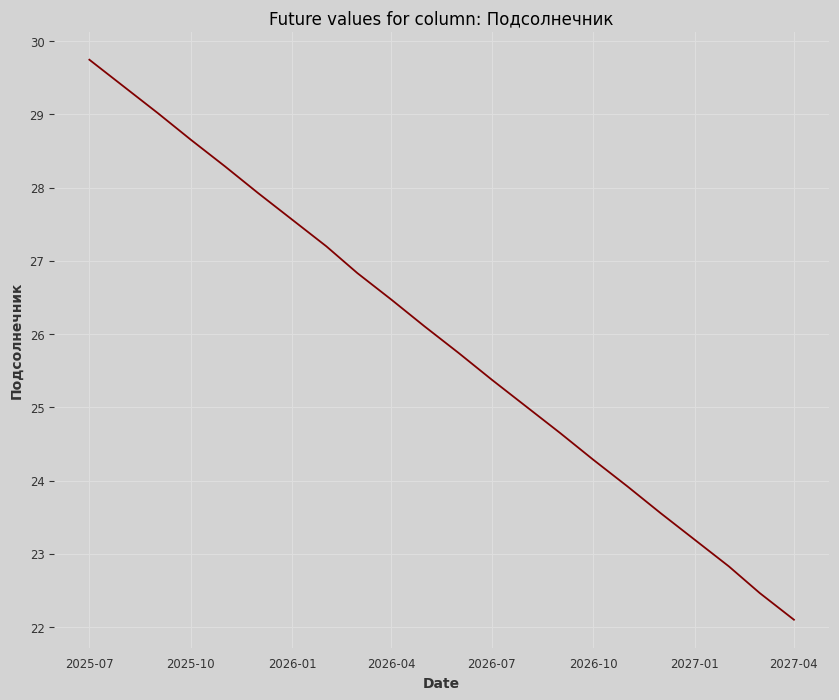

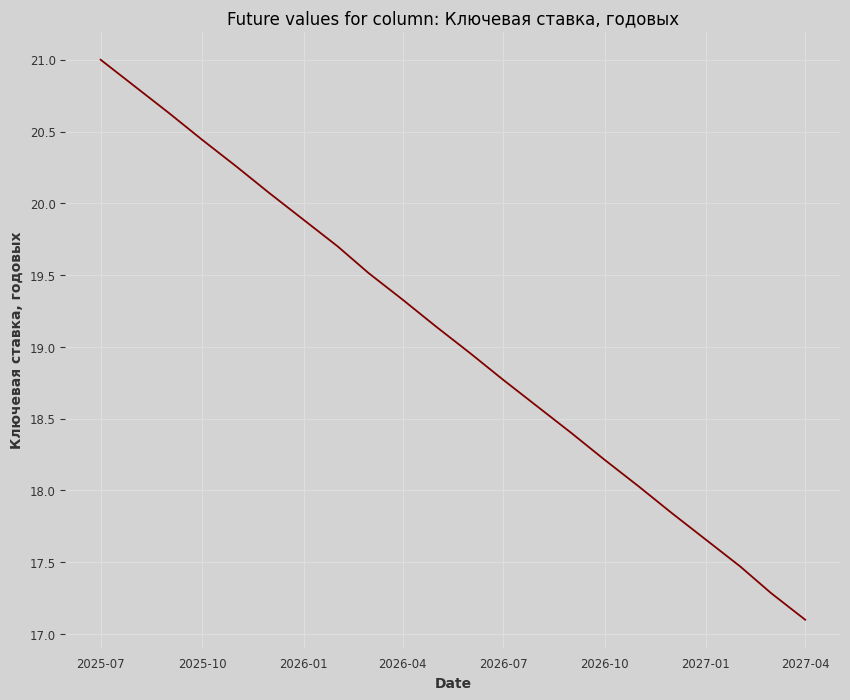

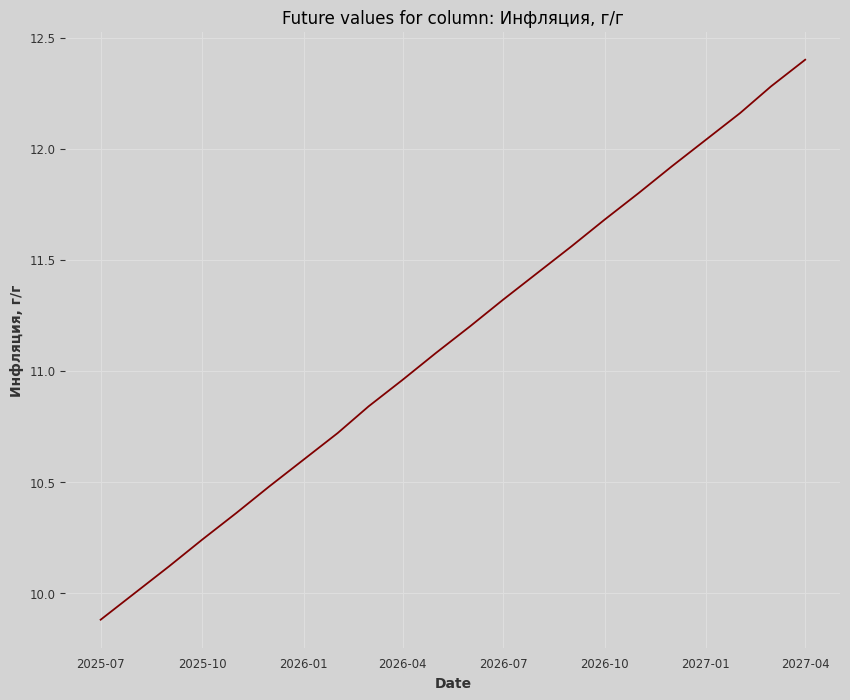

In [4]:
for ts_name, ts_val in zip(FUTURE_FORECASTER_TS_NAME, FUTURE_FORECASTER_TS_VALUES):
    plot_known_feature_value(ts_val,
                             ts_name,
                             pd.date_range(start=df_combined.index[-1] + pd.DateOffset(months=1) + pd.DateOffset(months=1),
                               periods=PREDICTION_HORIZON,
                               freq="MS"))

---
## Forecasting clusers

### predictions

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Ti Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.7 M  | train
---------

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

Saved forecaster to nbeats_dataset/nbeats_for_Fish.pkl and model to nbeats_dataset/nbeats_for_Fish_model.pth


...

Saved forecaster to nbeats_dataset/nbeats_for_Инфляция, г_г.pkl and model to nbeats_dataset/nbeats_for_Инфляция, г_г_model.pth


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.7 M  | train
-------------------------------------------------------------
6.7 M     Trainable params
1.8 K     Non-trainable params
6.7 M     Total params
26.776    Total estimated model params size (MB)
396       Modules in train mode
0         Modules in eval mode


Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=100` reached.


Saved forecaster to nbeats_dataset/nbeats_for_Ключевая ставка, годовых.pkl and model to nbeats_dataset/nbeats_for_Ключевая ставка, годовых_model.pth


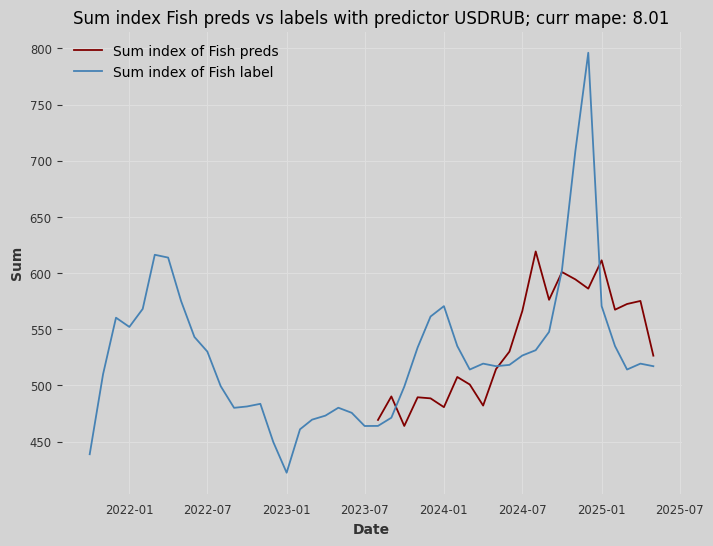

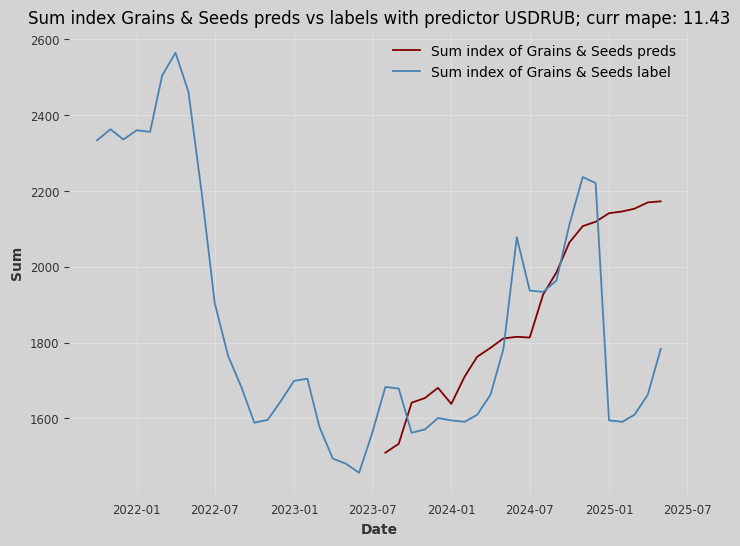

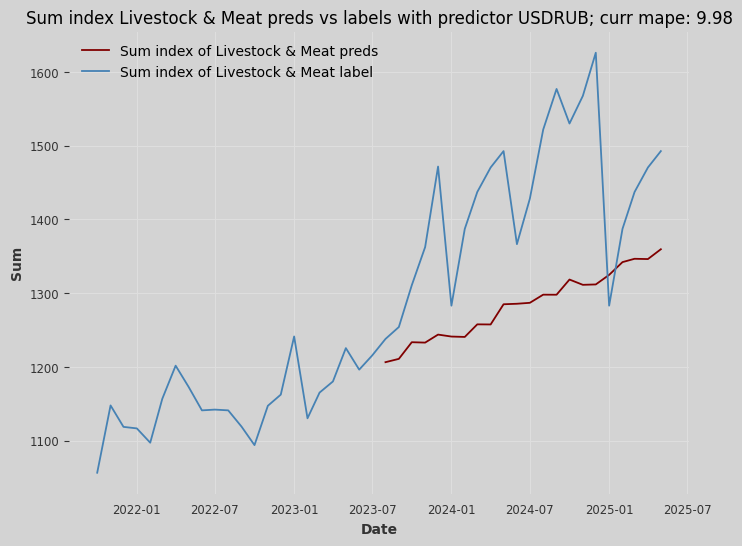

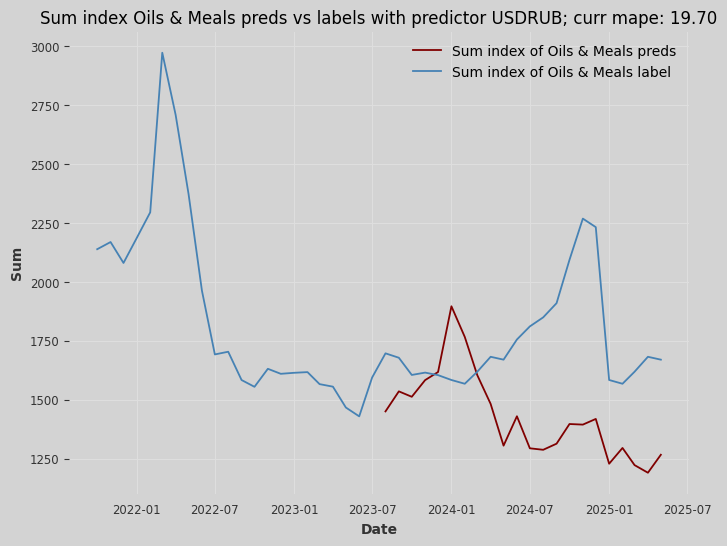

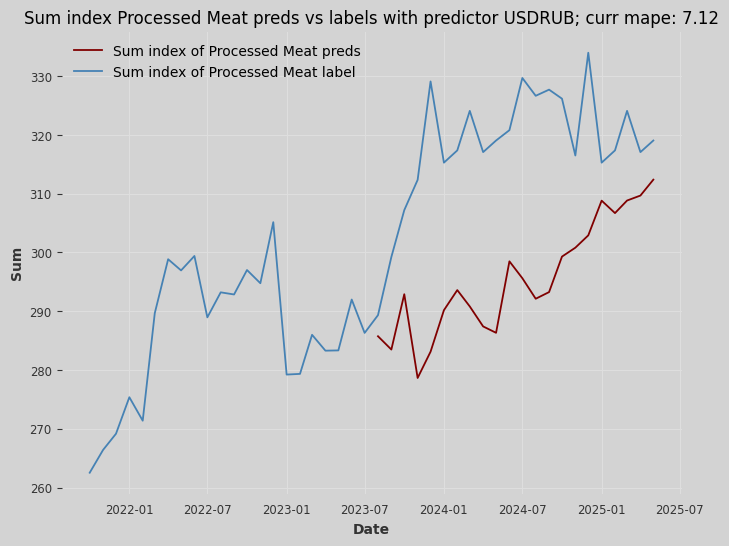

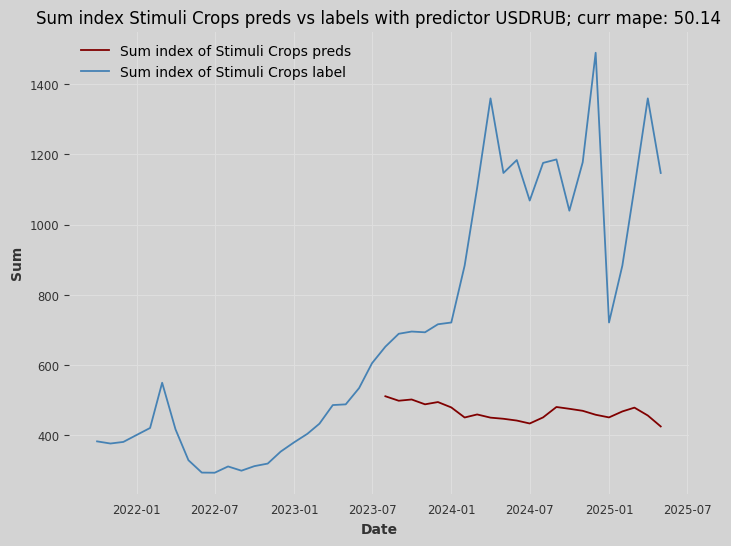

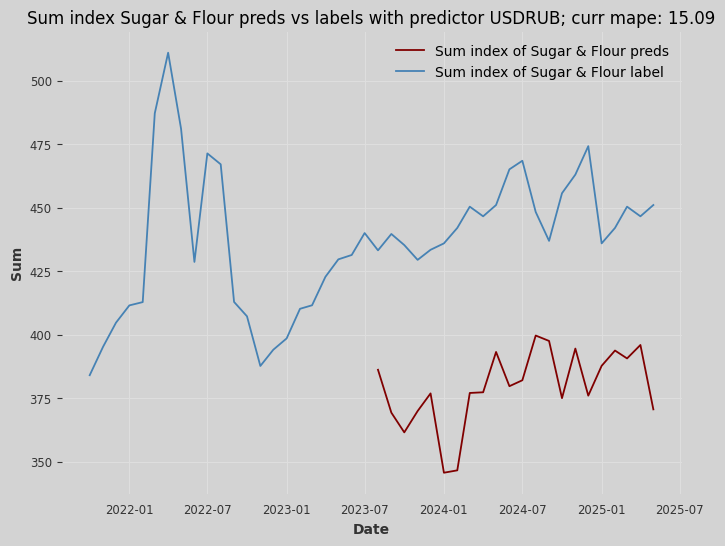

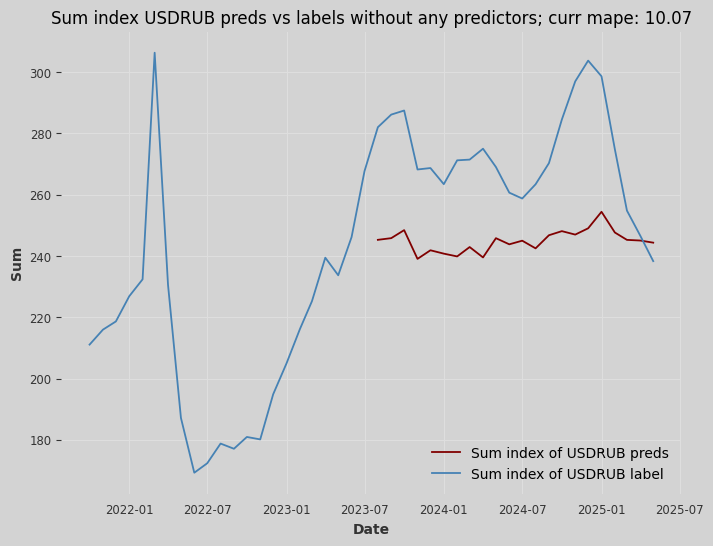

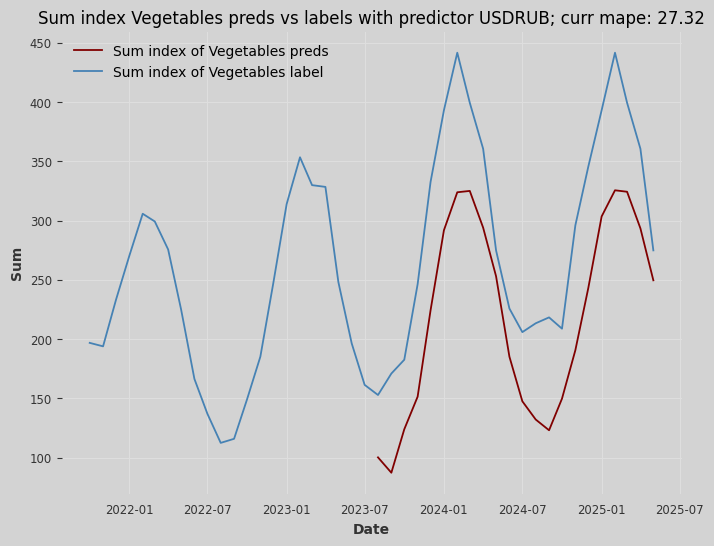

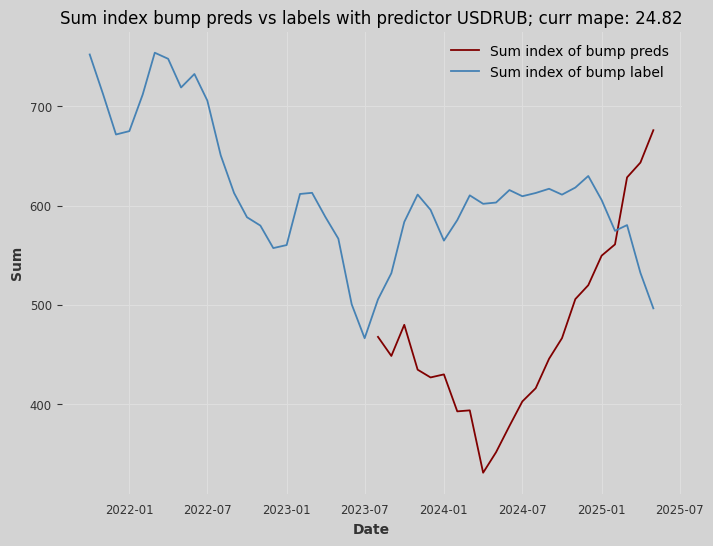

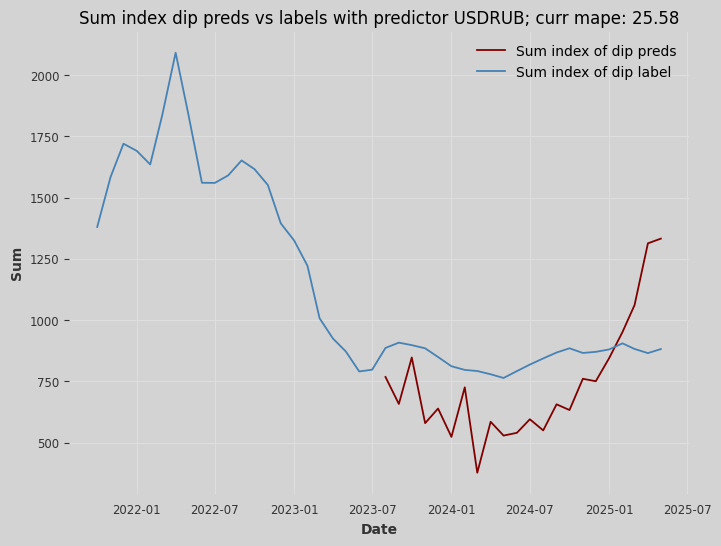

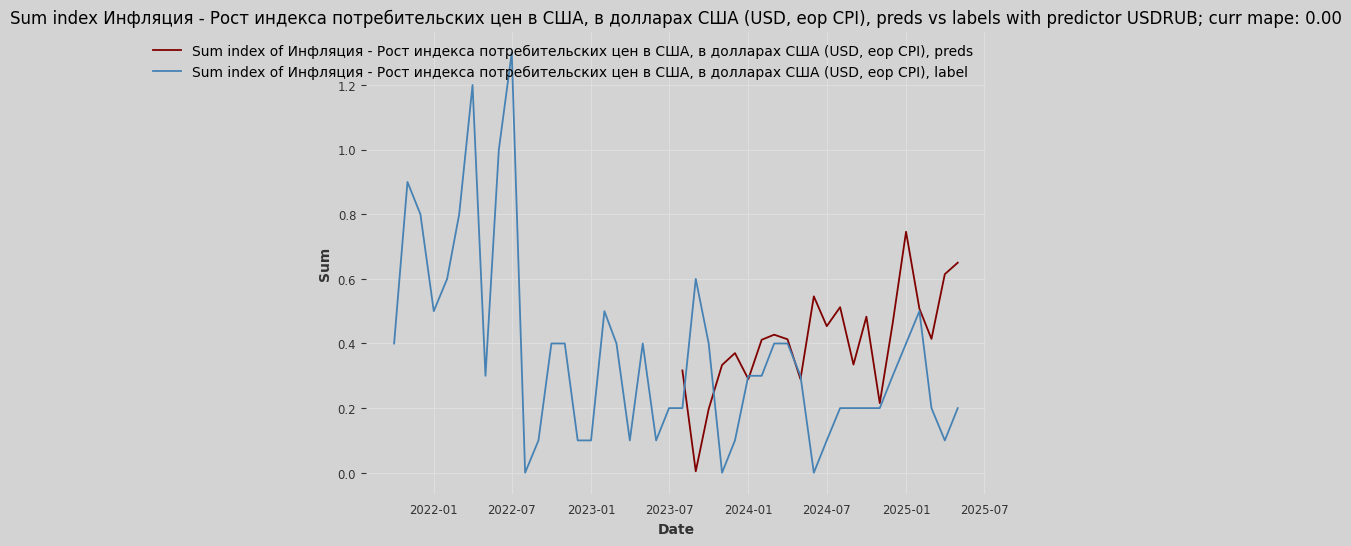

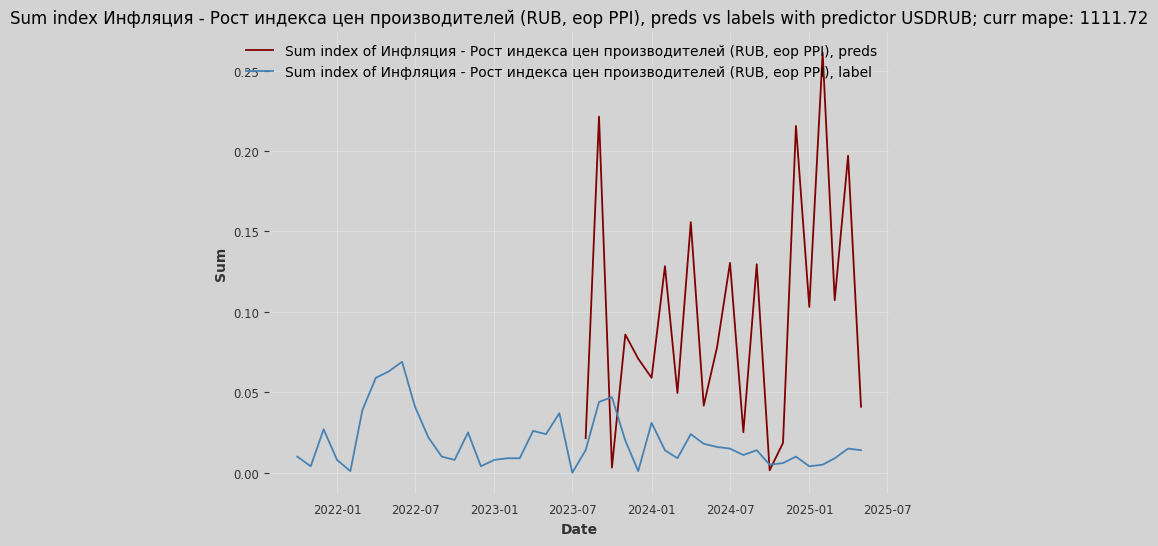

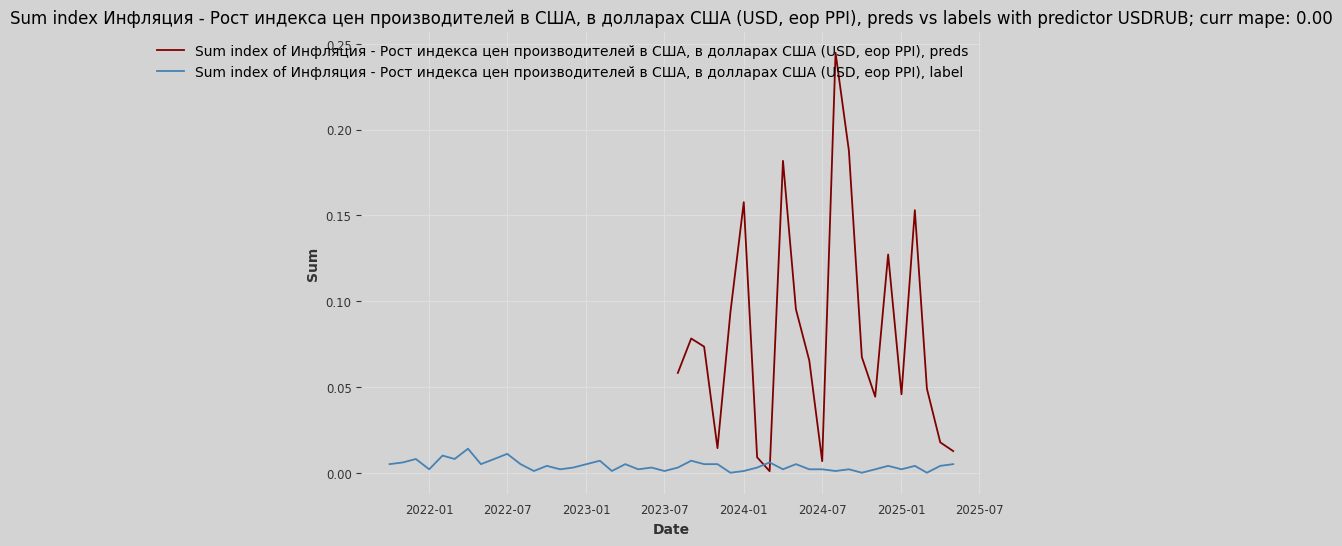

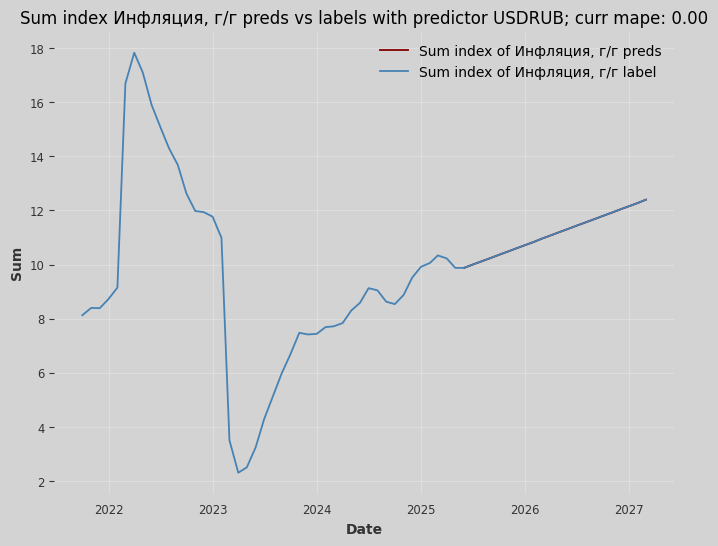

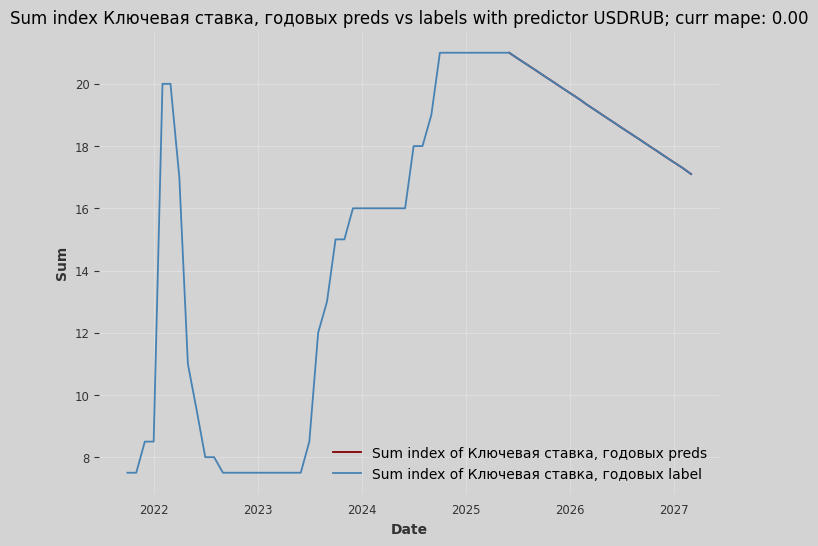

In [5]:
models = train_model_and_eval_res(df_updated,
                         macro_updated,
                         past_idx = past_idx,
                         future_idx = future_idx,
                         predict_up_to=SINGLE_DATAPOINT_TO_PRED,
                         category_map = CATEGORY_MAP,
                         best_predictors_for_idx = BEST_PREDICTORS_FOR_INDEX,
                         target_col_suffix = TARGET_COL_SUFFIX,
                         future_forecaster_ts_name = FUTURE_FORECASTER_TS_NAME,
                         future_forecaster_ts_values = FUTURE_FORECASTER_TS_VALUES,
                         model_name = MODEL_NAME_FOR_FORECASTER,
                         use_future_macro = USE_FUTURE_COV,
                         prediction_horizon = PREDICTION_HORIZON,
                         dir_to_save_plots = f"darts_result_pairs_{MODEL_NAME_FOR_FORECASTER}",
                         dir_to_save_tables = f"darts_result_tables_pairs_{MODEL_NAME_FOR_FORECASTER}",
                         persist_model=PERSIST_MODEL,
                         refit=REFIT_MODEL,
                         prediction_lag=PREDICTOR_LAG,
                         is_backtest=IS_BACKTEST,
                         ts_freq=TS_FREQUENCY
)
# TODO: Научинтся конвертить в TimeSeries

---
## Inference model

In [8]:
TARGET_COL_SUFFIX = "_norm_sum"

In [9]:
models = load_models(MODEL_NAME_FOR_FORECASTER, MODEL_SAVE_PATH)

[OK] Loaded forecaster ← nbeats_dataset/nbeats_for_Sugar & Flour.pkl
[OK] Loaded model      ← nbeats_dataset/nbeats_for_Sugar & Flour_model.pth
[OK] Loaded forecaster ← nbeats_dataset/nbeats_for_Ключевая ставка, годовых.pkl
[OK] Loaded model      ← nbeats_dataset/nbeats_for_Ключевая ставка, годовых_model.pth
[OK] Loaded forecaster ← nbeats_dataset/nbeats_for_Grains & Seeds.pkl
[OK] Loaded model      ← nbeats_dataset/nbeats_for_Grains & Seeds_model.pth
[OK] Loaded forecaster ← nbeats_dataset/nbeats_for_Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),.pkl
[OK] Loaded model      ← nbeats_dataset/nbeats_for_Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),_model.pth
[OK] Loaded forecaster ← nbeats_dataset/nbeats_for_Инфляция - Рост индекса цен производителей (RUB, eop PPI),.pkl
[OK] Loaded model      ← nbeats_dataset/nbeats_for_Инфляция - Рост индекса цен производителей (RUB, eop PPI),_model.pth
[OK] Loaded forecaster ← nbe

In [ ]:
answer_last = pd.DataFrame([])
df_updated.columns = [col_name.replace("/", " ") for col_name in df_updated.columns]

for col in CATEGORY_MAP.keys():
    is_predicting_macro = col in macro_updated.columns
    df_for_col = macro_updated if is_predicting_macro else df_updated
    if col in ('Подсолнечное масло (наливом) не бутилированное, не'):
        continue
    category_to_pred = CATEGORY_MAP.get(col, "")
    if category_to_pred == "":
        continue

    cluster_preds, ts_prediction = get_prediction_for_ts(df_updated,
                                                          models[category_to_pred],
                                                          col,
                                                          MODEL_NAME_FOR_FORECASTER,
                                                          macro_updated,
                                                          past_idx,
                                                          future_idx,
                                                          CATEGORY_MAP,
                                                          BEST_PREDICTORS_FOR_INDEX,
                                                          TARGET_COL_SUFFIX,
                                                          FUTURE_FORECASTER_TS_NAME,
                                                          FUTURE_FORECASTER_TS_VALUES,
                                                          USE_FUTURE_COV,
                                                          PREDICTION_HORIZON,
                                                          IS_BACKTEST,
                                                          PREDICTOR_LAG,
                                                          new_dates
                                                        )
    answer_last = pd.concat([answer_last, ts_prediction], axis=1)
    plot_graphics_for_each_ts(df_for_col[f"{col}"],
                          ts_prediction[f"{col}_preds"],
                          None,
                          col,
                          -1,
                          -1,
                          BEST_PREDICTORS_FOR_INDEX[CATEGORY_MAP[col]],
                          "",
                          forecasting_horizon=PREDICTION_HORIZON)
answer_last.to_excel(f"prediction_up_to_2025_{MODEL_NAME_FOR_FORECASTER}_new_3.xlsx")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Predicting: |                                                                                    | 0/? [00:00<…

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…